# Eurostat EDA
Preparation for Stand-Up meeting on June 2d, 2026

## Configuration:
### Install & Import Exploration Tools
Installing important libraries and `sqlalchemy` (needed to install it into dbt_project conda enviroment as well):

In [110]:
import os
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import numpy as np

# Load your database credentials
load_dotenv(dotenv_path='.env')

True

### Set the countries of interest (EU)

In [111]:
eu_countries = (
        'BE', 'BG', 'CZ', 'DK', 'DE', 'EE', 'IE', 'EL', 'ES', 'FR', 
        'HR', 'IT', 'CY', 'LV', 'LT', 'LU', 'HU', 'MT', 'NL', 'AT', 
        'PL', 'PT', 'RO', 'SI', 'SK', 'FI', 'SE'
)

### Establish the Connection Engine
Instead of basic raw cursors, Pandas uses a SQLAlchemy engine connection to smoothly stream rows straight into tabular DataFrames.

In [112]:
db_name = os.getenv("DB_NAME")
db_user = os.getenv("DB_USER")

# Format: postgresql://username@localhost/database_name
engine = create_engine(f"postgresql://{db_user}@localhost/{db_name}")

### Stream a Table straight into a Pandas DataFrame
Now I can read any raw table or execute a direct SQL query right into a DataFrame using `pd.read_sql()`. Example here is about the AI usage table:

In [113]:
# just the data from one table:
df_survey = pd.read_sql("SELECT * FROM public.isoc_ai_iaiu", con=engine)

In [114]:
df_survey

,freq,ind_type,indic_is,unit,country,year_2025
0,A,CB_EU_FOR,I_IUAI,PC_IND,AT,43.00
1,A,CB_EU_FOR,I_IUAI,PC_IND,BE,44.08
2,A,CB_EU_FOR,I_IUAI,PC_IND,BG,NaN
3,A,CB_EU_FOR,I_IUAI,PC_IND,CY,29.03
4,A,CB_EU_FOR,I_IUAI,PC_IND,CZ,27.73
...,...,...,...,...,...,...
39001,A,Y75_89ME,I_IUAIWP,PC_IND_IUAI,NO,NaN
39002,A,Y75_89ME,I_IUAIWP,PC_IND_IUAI,PL,NaN
39003,A,Y75_89ME,I_IUAIWP,PC_IND_IUAI,SE,NaN
39004,A,Y75_89ME,I_IUAIWP,PC_IND_IUAI,SI,NaN


In [115]:
df_survey['indic_is'].unique()

array(['I_IUAI', 'I_IUAIFE', 'I_IUAIPR', 'I_IUAIWP'], dtype=object)

In [116]:
# or just special individual types (IND_TOTAL) and special unit (PC_IND, percentage of individuals) 
# and for each indicator:
# I_IUAI = usage of AI in the last 3 month
# I_IUAIFE = -''-  for formal education
# I_IUAIPR = -''- for private purposes
# I_IUAIWP = -''- for professional (work) purposes

query = f"""
    SELECT 
        s.*, 
        m.indicator_name 
    FROM public.isoc_ai_iaiu s
    LEFT JOIN public.eurostat_indicators m 
      ON s.indic_is = m.indicator_code
    WHERE s.ind_type = 'IND_TOTAL' 
        and s.indic_is = 'I_IUAI' 
        and s.unit = 'PC_IND'
        and s.country in {eu_countries};
"""
df_combined = pd.read_sql(query, con=engine)

In [117]:
df_combined.head(3)

,freq,ind_type,indic_is,unit,country,year_2025,indicator_name
0,A,IND_TOTAL,I_IUAI,PC_IND,AT,39.42,Use of generative AI tools: in the last 3 months
1,A,IND_TOTAL,I_IUAI,PC_IND,BE,42.01,Use of generative AI tools: in the last 3 months
2,A,IND_TOTAL,I_IUAI,PC_IND,BG,22.50,Use of generative AI tools: in the last 3 months


In [118]:
df_combined.describe()

,year_2025
count,27.000000
mean,36.735926
std,8.800962
min,17.760000
25%,31.520000
50%,37.880000
75%,44.145000
max,48.440000


Small viz of AI Usage in the last 3 month by individual in the EU countries (2025):

In [119]:
df_combined.head(3)

,freq,ind_type,indic_is,unit,country,year_2025,indicator_name
0,A,IND_TOTAL,I_IUAI,PC_IND,AT,39.42,Use of generative AI tools: in the last 3 months
1,A,IND_TOTAL,I_IUAI,PC_IND,BE,42.01,Use of generative AI tools: in the last 3 months
2,A,IND_TOTAL,I_IUAI,PC_IND,BG,22.50,Use of generative AI tools: in the last 3 months


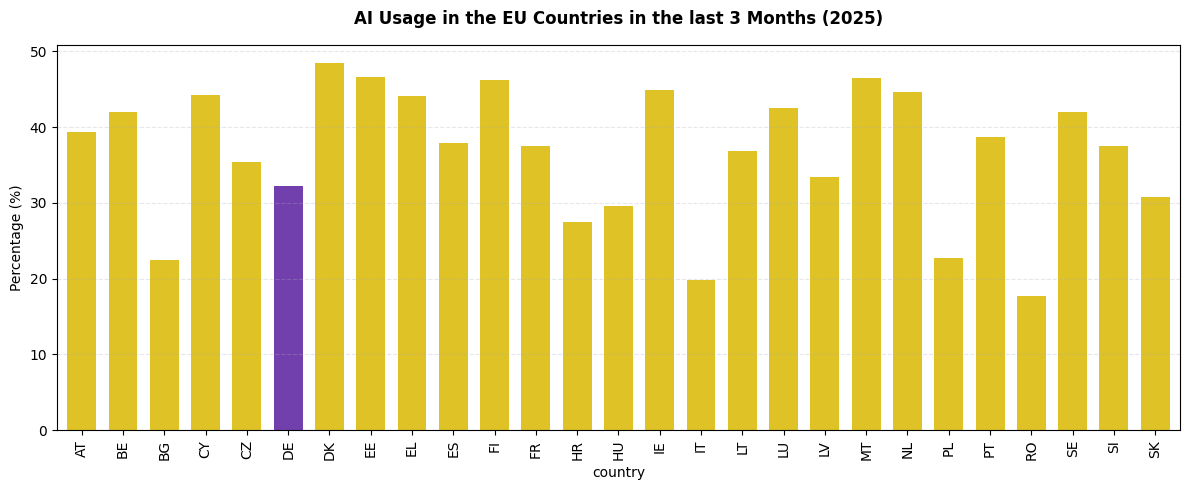

In [120]:
import matplotlib.pyplot as plt

# 1. Isolate the data series directly
plot_data = df_combined.set_index('country')['year_2025']

# 2. Define colors inline (DE gets purple, everything else gets yellow)
colors = ['#7140AD' if c == 'DE' else '#DEC226' for c in plot_data.index]

# 3. Plot and style everything in one clean block
plt.figure(figsize=(12, 5))
plot_data.plot(kind='bar', color=colors, width=0.7)

plt.title('AI Usage in the EU Countries in the last 3 Months (2025)', fontweight='bold', pad=15)
plt.ylabel('Percentage (%)')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [121]:
# or just special individual types (IND_TOTAL) and special unit (PC_IND, percentage of individuals) 
# and for each indicator:
# I_IUAI = usage of AI in the last 3 month
# I_IUAIFE = -''-  for formal education
# I_IUAIPR = -''- for private purposes
# I_IUAIWP = -''- for professional (work) purposes

query_per = f"""
    SELECT 
        s.*, 
        m.indicator_name 
    FROM public.isoc_ai_iaiu s
    LEFT JOIN public.eurostat_indicators m 
      ON s.indic_is = m.indicator_code
    WHERE s.ind_type = 'IND_TOTAL' 
        and s.indic_is = 'I_IUAIPR' 
        and s.unit = 'PC_IND'
        and s.country in {eu_countries};
"""
df_combined_per = pd.read_sql(query_per, con=engine)

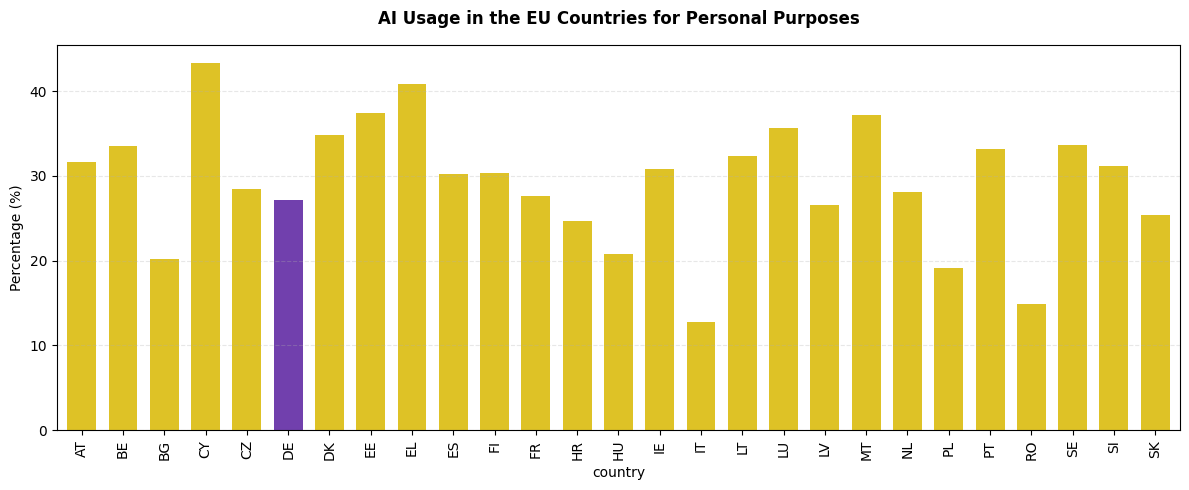

In [122]:
plot_data = df_combined_per.set_index('country')['year_2025']

colors = ['#7140AD' if c == 'DE' else '#DEC226' for c in plot_data.index]

plt.figure(figsize=(12, 5))
plot_data.plot(kind='bar', color=colors, width=0.7)

plt.title('AI Usage in the EU Countries for Personal Purposes', fontweight='bold', pad=15)
plt.ylabel('Percentage (%)')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [123]:
# or just special individual types (IND_TOTAL) and special unit (PC_IND, percentage of individuals) 
# and for each indicator:
# I_IUAI = usage of AI in the last 3 month
# I_IUAIFE = -''-  for formal education
# I_IUAIPR = -''- for private purposes
# I_IUAIWP = -''- for professional (work) purposes

query_work = f"""
    SELECT 
        s.*, 
        m.indicator_name 
    FROM public.isoc_ai_iaiu s
    LEFT JOIN public.eurostat_indicators m 
      ON s.indic_is = m.indicator_code
    WHERE s.ind_type = 'IND_TOTAL' 
        and s.indic_is = 'I_IUAIWP' 
        and s.unit = 'PC_IND'
        and s.country in {eu_countries};
"""
df_combined_work = pd.read_sql(query_work, con=engine)

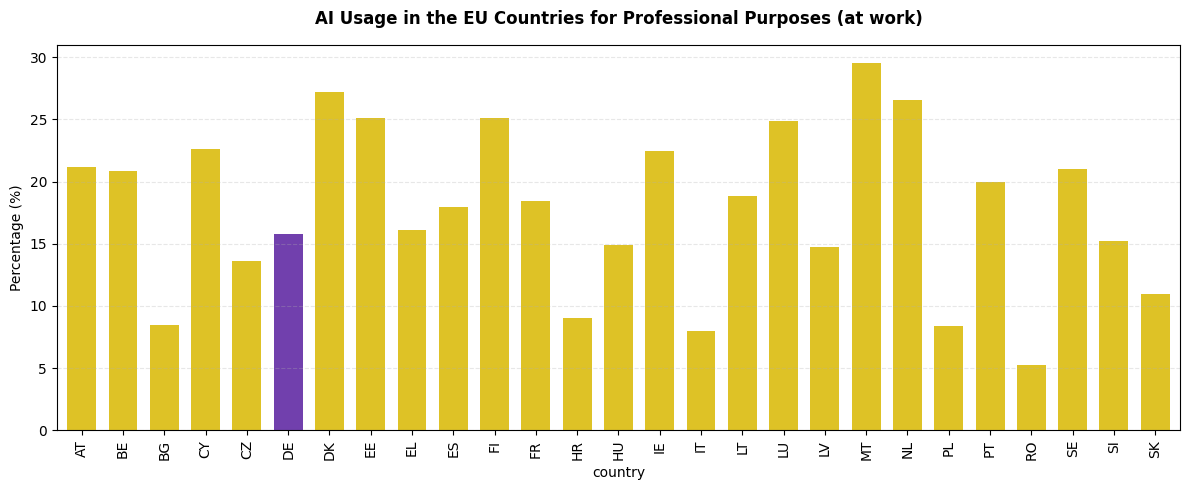

In [124]:
plot_data = df_combined_work.set_index('country')['year_2025']

colors = ['#7140AD' if c == 'DE' else '#DEC226' for c in plot_data.index]

plt.figure(figsize=(12, 5))
plot_data.plot(kind='bar', color=colors, width=0.7)

plt.title('AI Usage in the EU Countries for Professional Purposes (at work)', fontweight='bold', pad=15)
plt.ylabel('Percentage (%)')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## Another table: `isoc_ciegi_ac`: E-government activities of individuals via websites

In [125]:
df_egov = pd.read_sql("SELECT * FROM public.isoc_ciegi_ac", con=engine)

In [126]:
df_egov.head(10)

,freq,indic_is,unit,ind_type,country,year_2008,year_2009,year_2010,year_2011,year_2012,...,year_2016,year_2017,year_2018,year_2019,year_2020,year_2021,year_2022,year_2023,year_2024,year_2025
0,A,I_IGOV12FM,PC_IND,CB_EU_FOR,AL,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A,I_IGOV12FM,PC_IND,CB_EU_FOR,AT,NaN,NaN,39.02,32.02,39.52,...,37.91,41.71,41.10,54.27,45.82,60.04,NaN,NaN,NaN,NaN
2,A,I_IGOV12FM,PC_IND,CB_EU_FOR,BA,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,16.06,14.72,19.60,NaN,NaN,NaN,NaN,NaN
3,A,I_IGOV12FM,PC_IND,CB_EU_FOR,BE,NaN,NaN,NaN,20.87,24.91,...,27.36,29.86,26.48,32.39,38.85,53.97,NaN,NaN,NaN,NaN
4,A,I_IGOV12FM,PC_IND,CB_EU_FOR,BG,NaN,NaN,NaN,NaN,NaN,...,12.23,28.74,23.72,28.55,22.19,NaN,NaN,NaN,NaN,NaN
5,A,I_IGOV12FM,PC_IND,CB_EU_FOR,CH,NaN,NaN,NaN,NaN,NaN,...,NaN,56.03,NaN,54.82,NaN,NaN,NaN,NaN,NaN,NaN
6,A,I_IGOV12FM,PC_IND,CB_EU_FOR,CY,NaN,NaN,23.98,16.94,18.36,...,24.96,25.36,22.21,29.15,23.16,22.97,NaN,NaN,NaN,NaN
7,A,I_IGOV12FM,PC_IND,CB_EU_FOR,CZ,NaN,NaN,10.89,22.23,18.82,...,11.13,24.22,31.10,29.73,21.95,25.51,NaN,NaN,NaN,NaN
8,A,I_IGOV12FM,PC_IND,CB_EU_FOR,DE,NaN,NaN,NaN,19.39,19.98,...,27.34,27.58,25.98,29.00,31.82,27.24,NaN,NaN,NaN,NaN
9,A,I_IGOV12FM,PC_IND,CB_EU_FOR,DK,NaN,NaN,51.15,51.29,51.23,...,51.98,46.30,49.46,52.17,46.83,53.11,NaN,NaN,NaN,NaN


In [127]:
df_egov.shape

(236515, 23)

In [128]:
df_egov['indic_is'].unique()

array(['I_IGOV12FM', 'I_IGOV12FM2', 'I_IGOV12IF', 'I_IGOV12IF2',
       'I_IGOV12RT', 'I_IGOVANYS', 'I_IGOVAPR', 'I_IGOVBE', 'I_IGOVDOC',
       'I_IGOVED', 'I_IGOVIDB', 'I_IGOVIP', 'I_IGOVIX', 'I_IGOVLIB',
       'I_IGOVMV', 'I_IGOVODC', 'I_IGOVPOST', 'I_IGOVRCC', 'I_IGOVRX',
       'I_IGOVSS', 'I_IGOVTAX', 'I_IGOVTAX1_SLF', 'I_IGOVTAX2',
       'I_IGOV_ANY', 'I_IUGOV1', 'I_IUGOV12'], dtype=object)

This table is too big so we can work with a selected units, indicators, and individual types:



In [129]:
query_gov = f"""
    SELECT 
        gov.*, 
        m.indicator_name 
    FROM public.isoc_ciegi_ac gov
    LEFT JOIN public.eurostat_indicators m 
      ON gov.indic_is = m.indicator_code
    WHERE gov.ind_type = 'IND_TOTAL' 
        and gov.indic_is = 'I_IGOV12FM' 
        and gov.unit = 'PC_IND'
        and gov.country in {eu_countries};
"""
df_egov = pd.read_sql(query_gov, con=engine)

In [130]:
df_egov.shape

(27, 24)

In [131]:
df_egov.head()

,freq,indic_is,unit,ind_type,country,year_2008,year_2009,year_2010,year_2011,year_2012,...,year_2017,year_2018,year_2019,year_2020,year_2021,year_2022,year_2023,year_2024,year_2025,indicator_name
0,A,I_IGOV12FM,PC_IND,IND_TOTAL,AT,35.40,31.14,33.12,37.61,33.91,...,38.27,38.40,44.27,46.29,56.02,None,None,None,None,Internet use: downloading official forms (last...
1,A,I_IGOV12FM,PC_IND,IND_TOTAL,BE,13.75,21.18,25.49,23.65,25.94,...,30.22,30.59,34.63,35.35,50.74,None,None,None,None,Internet use: downloading official forms (last...
2,A,I_IGOV12FM,PC_IND,IND_TOTAL,BG,5.88,7.05,11.33,9.38,13.18,...,10.45,9.37,12.47,14.38,13.39,None,None,None,None,Internet use: downloading official forms (last...
3,A,I_IGOV12FM,PC_IND,IND_TOTAL,CY,12.06,18.38,19.14,21.26,23.55,...,31.14,27.37,37.13,36.32,47.64,None,None,None,None,Internet use: downloading official forms (last...
4,A,I_IGOV12FM,PC_IND,IND_TOTAL,CZ,8.57,12.47,10.19,18.12,15.09,...,18.35,25.54,28.05,28.32,31.11,None,None,None,None,Internet use: downloading official forms (last...


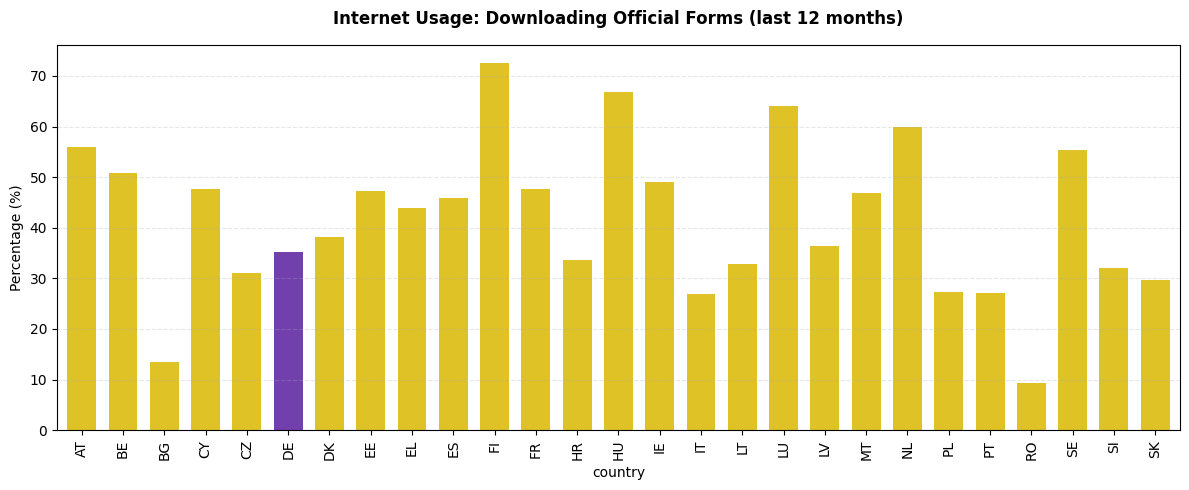

In [132]:
plot_data = df_egov.set_index('country')['year_2021']

colors = ['#7140AD' if c == 'DE' else '#DEC226' for c in plot_data.index]

plt.figure(figsize=(12, 5))
plot_data.plot(kind='bar', color=colors, width=0.7)

plt.title('Internet Usage: Downloading Official Forms (last 12 months)', fontweight='bold', pad=15)
plt.ylabel('Percentage (%)')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## `tin00129`:  Voting

In [133]:
df_vote = pd.read_sql("SELECT * FROM public.tin00129", con=engine)

In [134]:
df_vote

,freq,unit,indic_is,ind_type,country,year_2011,year_2013,year_2015,year_2017,year_2019,year_2021,year_2022,year_2023,year_2024,year_2025
0,A,PC_IND,I_IUVOTE,EMPL_UNE,AL,NaN,NaN,NaN,NaN,27.62,8.72,19.63,22.59,25.39,19.07
1,A,PC_IND,I_IUVOTE,EMPL_UNE,AT,9.21,12.82,8.09,6.39,8.74,14.19,14.89,13.52,11.58,14.05
2,A,PC_IND,I_IUVOTE,EMPL_UNE,BA,NaN,NaN,NaN,NaN,4.83,5.31,NaN,6.00,7.42,6.85
3,A,PC_IND,I_IUVOTE,EMPL_UNE,BE,2.33,3.98,5.39,6.05,5.83,5.55,6.78,6.85,9.02,6.55
4,A,PC_IND,I_IUVOTE,EMPL_UNE,BG,3.22,3.78,3.47,3.07,4.56,4.51,8.97,8.49,10.29,7.83
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,A,PC_IND,I_IUVOTE,Y55_74,SI,2.19,3.19,2.22,2.53,3.17,4.57,3.96,2.59,3.71,3.07
542,A,PC_IND,I_IUVOTE,Y55_74,SK,0.95,1.91,0.56,1.98,1.69,4.19,1.50,3.32,3.66,3.93
543,A,PC_IND,I_IUVOTE,Y55_74,TR,NaN,0.88,1.36,1.30,1.94,0.79,1.37,1.59,1.97,1.75
544,A,PC_IND,I_IUVOTE,Y55_74,UK,5.36,7.53,6.29,9.88,12.64,NaN,NaN,NaN,NaN,NaN


In [135]:
query_vote = f"""
    SELECT 
        tin.*, 
        m.indicator_name 
    FROM public.tin00129 as tin
    LEFT JOIN public.eurostat_indicators m 
      ON tin.indic_is = m.indicator_code
    WHERE tin.ind_type = 'IND_TOTAL' 
        and tin.indic_is = 'I_IUVOTE' 
        and tin.unit = 'PC_IND'
        and tin.country in {eu_countries};
"""
df_vote = pd.read_sql(query_vote, con=engine)

In [136]:
df_vote.shape

(27, 16)

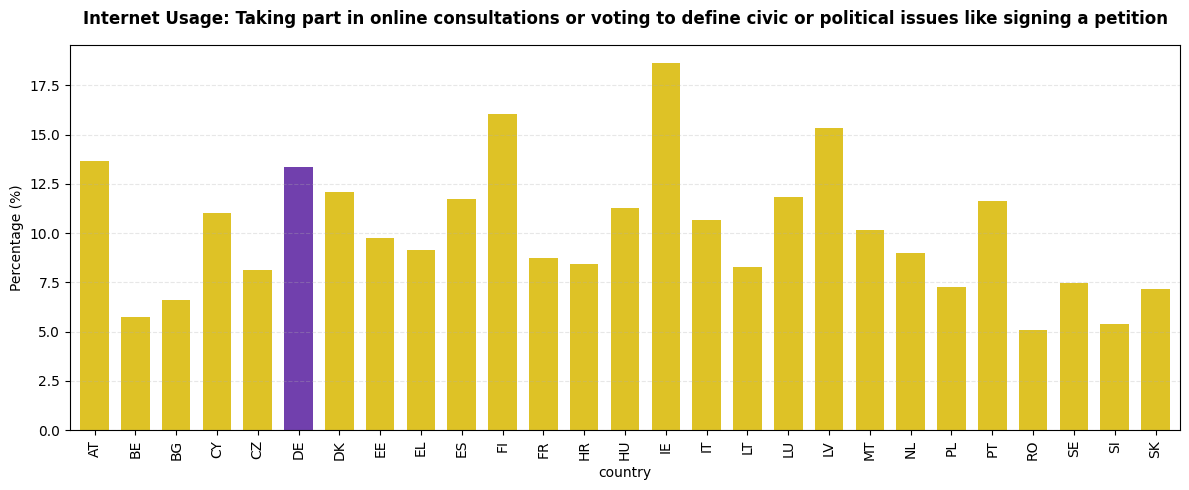

In [137]:
plot_data = df_vote.set_index('country')['year_2025']

colors = ['#7140AD' if c == 'DE' else '#DEC226' for c in plot_data.index]

plt.figure(figsize=(12, 5))
plot_data.plot(kind='bar', color=colors, width=0.7)

plt.title('Internet Usage: Taking part in online consultations or voting to define civic or political issues like signing a petition', fontweight='bold', pad=15)
plt.ylabel('Percentage (%)')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()